# US Quad Regime Analysis

Classify U.S. economic conditions into four regimes using the sign of **GDP YoY growth** and **Core CPI (CPILFENS) YoY growth**, then analyze the forward return of the S&P 500 under each regime.

| | **Inflation ↓ (CPI YoY < 0)** | **Inflation ↑ (CPI YoY ≥ 0)** |
|---|---|---|
| **Growth ↑ (GDP YoY > 0)** | Quad 1 — Disinflationary Growth | Quad 2 — Inflationary Growth |
| **Contraction ↓ (GDP YoY ≤ 0)** | Quad 3 — Deflationary Recession | Quad 4 — Stagflation |

**Data sources**
- GDP: BEA Vintage History (quarterly, full revision history, 2002 Q1–present)
- CPI: CPILFENS — Core CPI with vintage history (monthly)
- S&P 500: TradingView daily close prices

**Methodology notes**
- GDP is point-in-time (PIT): for each analysis month *T*, only vintages released on or before *T* are used — respecting the Advance/Second/Third publication schedule.
- CPI uses the first available vintage for each observation month (diagonal of the vintage matrix) plus a one-month publication lag.
- Forward returns are computed from end-of-month S&P 500 closes at horizons of 3 M, 6 M, and 12 M.

In [1]:
import re
import zipfile
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

ROOT = Path('../')

QUAD_COLORS = {1: '#27ae60', 2: '#e67e22', 3: '#2980b9', 4: '#c0392b'}
QUAD_LABELS = {
    1: 'Q1 — Disinflation Growth',
    2: 'Q2 — Inflationary Growth',
    3: 'Q3 — Deflationary Recession',
    4: 'Q4 — Stagflation',
}

## 1. S&P 500 Price Data

In [2]:
def load_spx() -> pd.Series:
    """Combine both TradingView CSVs and return end-of-month close prices."""
    idx_dir = ROOT / 'data/tradingview/global_stock_indexes'
    frames = []
    for f in sorted(idx_dir.glob('*.csv')):
        df = pd.read_csv(f, usecols=['time', 'close'])
        df['date'] = pd.to_datetime(df['time'], unit='s').dt.normalize()
        frames.append(df[['date', 'close']].set_index('date'))

    daily = (
        pd.concat(frames)
        .sort_index()
        .pipe(lambda x: x[~x.index.duplicated(keep='last')])
        .rename(columns={'close': 'spx'})
    )
    return daily['spx'].resample('ME').last().dropna()


spx = load_spx()
print(f'S&P 500: {spx.index[0].date()} to {spx.index[-1].date()} ({len(spx)} months)')
spx.tail()

S&P 500: 1999-11-30 to 2026-06-30 (320 months)


date
2026-02-28    684.121672
2026-03-31    650.340000
2026-04-30    718.660000
2026-05-31    756.480000
2026-06-30    737.550000
Freq: ME, Name: spx, dtype: float64

## 2. Core CPI — Point-in-Time Vintage

The vintage matrix rows = observation month, columns = release date.  
We take the **first non-NaN** value in each row (the initial release) to avoid look-ahead from revisions.  
A **one-month publication lag** is applied: regime at month *T* uses CPI from month *T−1*.

In [3]:
def load_cpi_pit() -> pd.DataFrame:
    """Return Core CPI first-release levels and YoY growth by observation month."""
    raw = pd.read_csv(
        ROOT / 'data/us/quad_regime/cpi_vintages_starting_1996-12-12.csv',
        index_col='observation_date',
        parse_dates=True,
    )
    vintage_cols = [c for c in raw.columns if c.startswith('CPILFENS_')]

    records = []
    for obs_date, row in raw[vintage_cols].iterrows():
        valid = row.dropna()
        if valid.empty:
            continue
        records.append({'obs_date': obs_date, 'cpi_level': valid.iloc[0]})

    df = (
        pd.DataFrame(records)
        .set_index('obs_date')
        .sort_index()
    )
    df['cpi_yoy'] = df['cpi_level'].pct_change(12) * 100
    return df[['cpi_level', 'cpi_yoy']]


cpi = load_cpi_pit()
print(f'Core CPI: {cpi.index[0].date()} to {cpi.index[-1].date()} ({len(cpi)} months)')
cpi.dropna().tail()

Core CPI: 1957-01-01 to 2026-04-01 (831 months)


,cpi_level,cpi_yoy
obs_date,,
2025-12-01,330.506,2.658512
2026-01-01,331.950,3.087821
2026-02-01,333.242,2.902650
2026-03-01,334.391,2.809821
2026-04-01,335.803,3.028230


## 3. Real GDP — Point-in-Time Vintage (BEA Revision History)

BEA publishes Advance, Second, Third, and subsequent revised estimates per quarter.  
For each analysis month *T* we use the **latest vintage released on or before *T*** for each quarter,  
then compute **nominal GDP YoY** (levels available in all vintages; sign aligns with real GDP YoY in virtually every historical episode).

> Advance released ~last day of month +1 after quarter end.  
> Second ~month +2; Third ~month +3.

In [4]:
def parse_gdp_vintages(xlsx_path: Path) -> pd.DataFrame:
    """
    Parse all GDP vintage records from the BEA xlsx without openpyxl.
    Returns long-format DataFrame: quarter, quarter_end, vintage_type,
    nominal_gdp, real_gdp_qoq_ann, release_date.
    """
    ns = {'ns': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
    quarter_re = re.compile(r'^(\d{4})Q([1-4])$')
    date_re    = re.compile(r'([A-Za-z]+ \d+,\s*\d{4})')
    skip_vals  = {
        'Vintage', 'Percent Change', 'from Preceding Period',
        'GDP', 'GDI', 'Real GDP', 'Real GDI', 'Release Date',
        'Billions of Current Dollars', '',
    }

    with zipfile.ZipFile(xlsx_path) as z:
        ss = ET.fromstring(z.read('xl/sharedStrings.xml'))
        strings = [
            ''.join(p.text or '' for p in si.findall('.//ns:t', ns))
            for si in ss.findall('ns:si', ns)
        ]
        ws   = ET.fromstring(z.read('xl/worksheets/sheet2.xml'))
        rows = ws.findall('.//ns:row', ns)

    def cell_val(row_elem, col_letter):
        for c in row_elem.findall('ns:c', ns):
            col = ''.join(ch for ch in c.get('r', '') if ch.isalpha())
            if col == col_letter:
                t = c.get('t', 'n')
                v = c.find('ns:v', ns)
                if v is None:
                    return None
                return strings[int(v.text)] if t == 's' else v.text
        return None

    def parse_float(s):
        if s is None or str(s).strip() in {'.....', '', 'N/A'}:
            return np.nan
        try:
            return float(str(s).replace(',', ''))
        except ValueError:
            return np.nan

    def to_quarter_end(label):
        m = quarter_re.match(label)
        yr, q = int(m.group(1)), int(m.group(2))
        return pd.Timestamp(year=yr, month=q * 3, day=1) + pd.offsets.MonthEnd(0)

    records, current_q, current_qend = [], None, None

    for row in rows:
        a = cell_val(row, 'A')
        b = cell_val(row, 'B')

        if a and quarter_re.match(a):           # new quarter block
            current_q, current_qend = a, to_quarter_end(a)
            continue

        if b is None or b in skip_vals or current_q is None:
            continue

        # B=vintage_type, C=nominal_gdp, D=gdi, E=real_gdp_qoq_ann, F=real_gdi, G=release_date
        g_raw      = cell_val(row, 'G') or ''
        date_match = date_re.search(g_raw)
        if not date_match:
            continue
        try:
            release_date = pd.to_datetime(date_match.group(1))
        except Exception:
            continue

        records.append({
            'quarter':          current_q,
            'quarter_end':      current_qend,
            'vintage_type':     b,
            'nominal_gdp':      parse_float(cell_val(row, 'C')),
            'real_gdp_qoq_ann': parse_float(cell_val(row, 'E')),
            'release_date':     release_date,
        })

    return pd.DataFrame(records)


gdp_vintages = parse_gdp_vintages(ROOT / 'data/us/quad_regime/gdp-gdi-vintage-history.xlsx')
print(f'GDP vintage records: {len(gdp_vintages)}')
print(f'Quarters: {gdp_vintages["quarter"].nunique()} | '
      f'Range: {gdp_vintages["quarter_end"].min().date()} to {gdp_vintages["quarter_end"].max().date()}')
gdp_vintages.head(8)

GDP vintage records: 1051
Quarters: 97 | Range: 2002-03-31 to 2026-03-31


,quarter,quarter_end,vintage_type,nominal_gdp,real_gdp_qoq_ann,release_date
0,2026Q1,2026-03-31,Second,31819.5,1.6,2026-05-28
1,2026Q1,2026-03-31,Advance,31856.3,2.0,2026-04-30
2,2025Q4,2025-12-31,Revised,31422.5,0.5,2026-05-28
3,2025Q4,2025-12-31,Third,31422.5,0.5,2026-04-09
4,2025Q4,2025-12-31,Second,31442.5,0.7,2026-03-13
5,2025Q4,2025-12-31,Advance,31490.1,1.4,2026-02-20
6,2025Q3,2025-09-30,Revised,31098.0,4.4,2026-03-13
7,2025Q3,2025-09-30,Updated,31098.0,4.4,2026-01-22


In [5]:
def build_gdp_yoy_pit(gdp_vintages: pd.DataFrame,
                       analysis_months: pd.DatetimeIndex) -> pd.Series:
    """
    For each analysis month T:
      1. For each quarter, take the latest vintage with release_date <= T.
      2. Compute nominal GDP YoY using the most recent available quarter vs 4 quarters prior.
    Returns Series indexed by analysis_month.
    """
    quarters = sorted(gdp_vintages['quarter_end'].unique())

    # Wide PIT table: rows = analysis_months, cols = quarter_end dates
    pit_wide = pd.DataFrame(index=analysis_months, dtype=float)

    for qend in quarters:
        q_data = (
            gdp_vintages[gdp_vintages['quarter_end'] == qend]
            .sort_values('release_date')[['release_date', 'nominal_gdp']]
            .dropna(subset=['nominal_gdp'])
        )
        if q_data.empty:
            continue
        merged = pd.merge_asof(
            pd.DataFrame({'analysis_date': analysis_months}),
            q_data,
            left_on='analysis_date',
            right_on='release_date',
            direction='backward',
        )
        pit_wide[qend] = merged['nominal_gdp'].values

    results = {}
    for t in analysis_months:
        row   = pit_wide.loc[t].dropna()
        if row.empty:
            continue
        latest_q = row.index[-1]
        target_q = latest_q - pd.DateOffset(years=1)

        # Find prior quarter within ±46 days of target (handles month-end edge cases)
        prior_cands = row.index[
            (row.index >= target_q - pd.Timedelta(days=46)) &
            (row.index <= target_q + pd.Timedelta(days=46))
        ]
        if len(prior_cands) == 0:
            continue
        prior_q = prior_cands[-1]

        gdp_now, gdp_then = row[latest_q], row[prior_q]
        if pd.notna(gdp_now) and pd.notna(gdp_then) and gdp_then != 0:
            results[t] = (gdp_now / gdp_then - 1) * 100

    return pd.Series(results, name='gdp_yoy')


analysis_months = pd.date_range(start='2002-01-31', end=spx.index[-1], freq='ME')

gdp_yoy = build_gdp_yoy_pit(gdp_vintages, analysis_months)
print(f'GDP YoY PIT: {gdp_yoy.dropna().index[0].date()} to {gdp_yoy.dropna().index[-1].date()}')
gdp_yoy.dropna().tail()

GDP YoY PIT: 2003-04-30 to 2026-06-30


2026-02-28    5.582192
2026-03-31    5.422596
2026-04-30    6.038859
2026-05-31    5.916364
2026-06-30    5.916364
Name: gdp_yoy, dtype: float64

## 4. Align to Monthly Frequency & Assign Regimes

| Signal | Lag logic |
|---|---|
| GDP YoY | PIT via vintage release dates; carried forward within quarter via `ffill` |
| CPI YoY | Observation month *M* data available from *M+1*; index shifted forward by 1 month |
| S&P 500 | End-of-month close; used as both regime entry price and forward return base |

In [6]:
def classify_regime(gdp_yoy: float, cpi_yoy: float):
    if pd.isna(gdp_yoy) or pd.isna(cpi_yoy):
        return np.nan
    if   gdp_yoy >  0 and cpi_yoy <  0: return 1  # Disinflationary Growth
    elif gdp_yoy >  0 and cpi_yoy >= 0: return 2  # Inflationary Growth
    elif gdp_yoy <= 0 and cpi_yoy <  0: return 3  # Deflationary Recession
    else:                                return 4  # Stagflation


# CPI: shift observation index forward by 1 month to reflect publication lag
cpi_lagged = cpi['cpi_yoy'].copy()
cpi_lagged.index = cpi_lagged.index + pd.offsets.MonthEnd(1)

# GDP: forward-fill within each quarter (quarterly data, monthly analysis)
gdp_monthly = gdp_yoy.reindex(analysis_months).ffill()

master = pd.DataFrame({
    'spx':     spx,
    'gdp_yoy': gdp_monthly,
    'cpi_yoy': cpi_lagged,
}).dropna(subset=['spx'])

master['regime'] = master.apply(
    lambda r: classify_regime(r['gdp_yoy'], r['cpi_yoy']), axis=1
)

print(f'Master dataset: {master.index[0].date()} to {master.index[-1].date()} ({len(master)} months)\n')
regime_counts = master.dropna(subset=['regime'])['regime'].value_counts().sort_index()
total = regime_counts.sum()
for q, n in regime_counts.items():
    print(f'  {QUAD_LABELS[int(q)]:<35} {n:>4} months  ({n/total:.1%})')

master.dropna().tail(6)

Master dataset: 1999-11-30 to 2026-06-30 (320 months)

  Q2 — Inflationary Growth             258 months  (93.5%)
  Q4 — Stagflation                      18 months  (6.5%)


,spx,gdp_yoy,cpi_yoy,regime
2025-11-30,679.520479,4.592926,2.693639,2.0
2025-12-31,680.062757,5.365330,2.658512,2.0
2026-01-31,690.085385,5.375156,3.087821,2.0
2026-02-28,684.121672,5.582192,2.902650,2.0
2026-03-31,650.340000,5.422596,2.809821,2.0
2026-04-30,718.660000,6.038859,3.028230,2.0


## 5. Regime Timeline

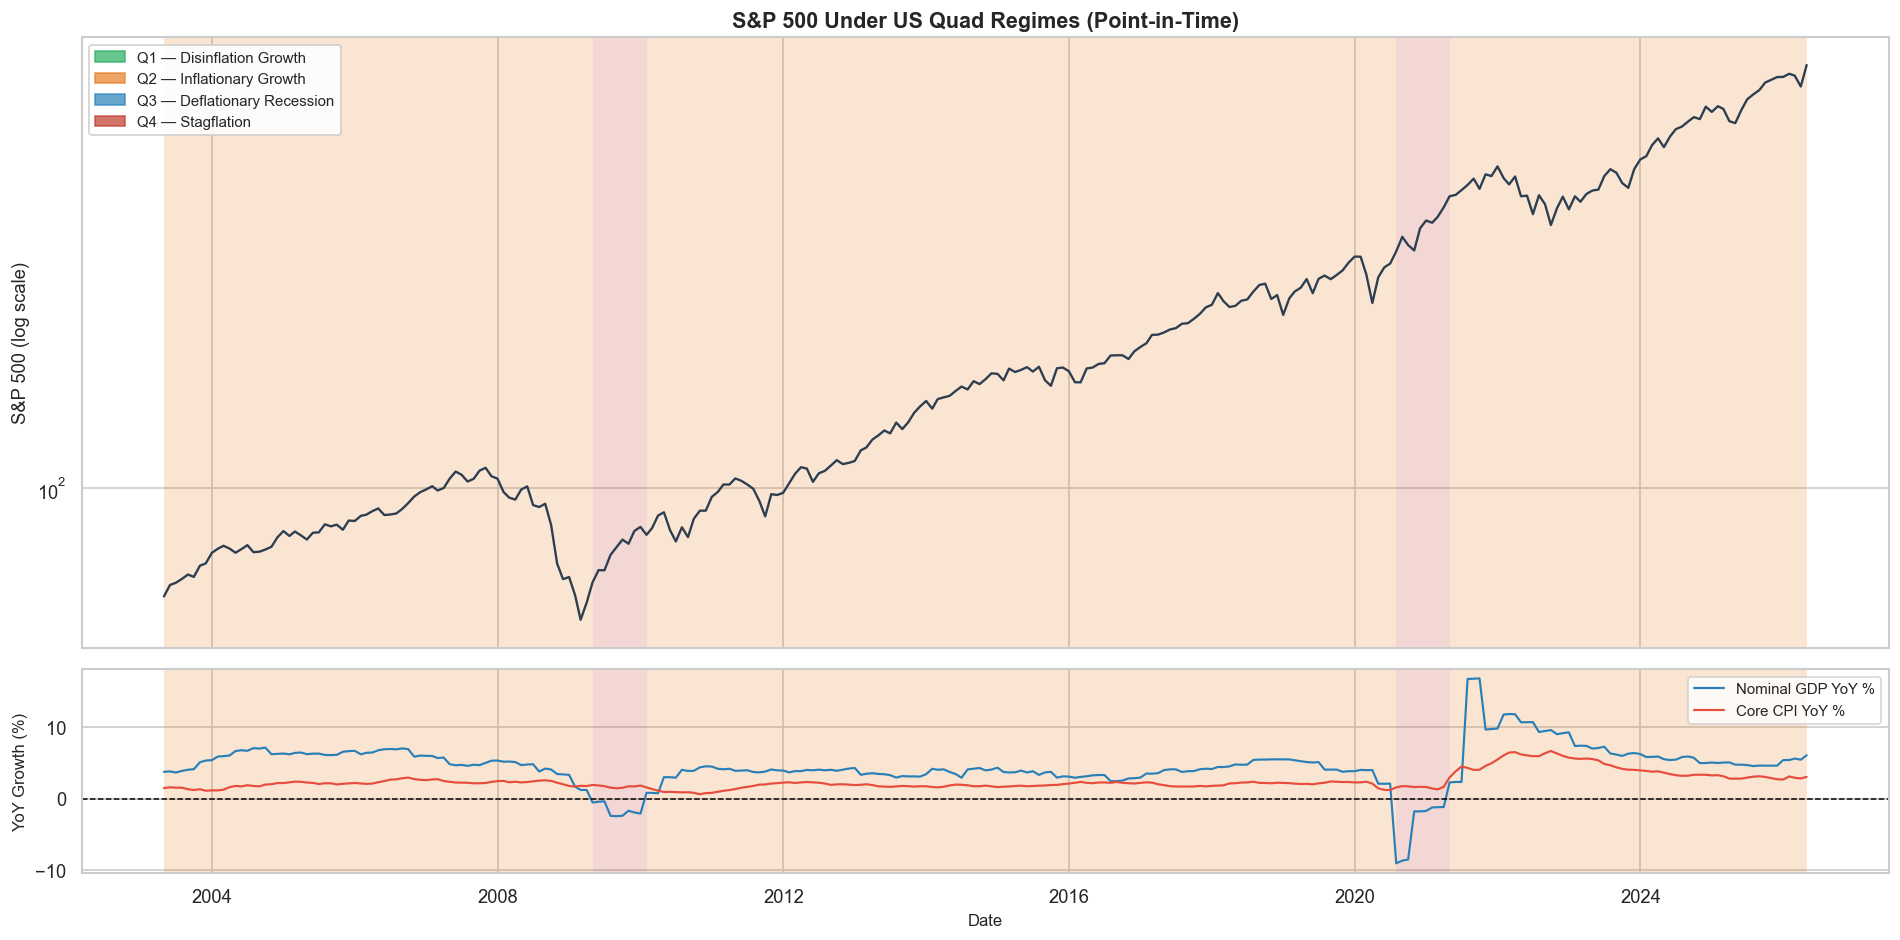

In [7]:
plot_df = master.dropna(subset=['regime', 'spx'])

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)

# ── Top: SPX price (log) with regime shading ─────────────────────────────────
ax_top.plot(plot_df.index, plot_df['spx'], color='#2c3e50', lw=1.4, zorder=5)
ax_top.set_yscale('log')
ax_top.set_ylabel('S&P 500 (log scale)', fontsize=11)
ax_top.set_title('S&P 500 Under US Quad Regimes (Point-in-Time)', fontsize=13, fontweight='bold')

prev_r, span_start = None, None
for date, row in plot_df.iterrows():
    r = int(row['regime'])
    if r != prev_r:
        if prev_r is not None:
            for ax in (ax_top, ax_bot):
                ax.axvspan(span_start, date, color=QUAD_COLORS[prev_r], alpha=0.20, lw=0)
        span_start, prev_r = date, r
if prev_r is not None:
    for ax in (ax_top, ax_bot):
        ax.axvspan(span_start, plot_df.index[-1], color=QUAD_COLORS[prev_r], alpha=0.20, lw=0)

patches = [mpatches.Patch(color=QUAD_COLORS[q], alpha=0.7, label=QUAD_LABELS[q]) for q in range(1, 5)]
ax_top.legend(handles=patches, loc='upper left', fontsize=9, framealpha=0.9)

# ── Bottom: GDP YoY and CPI YoY ──────────────────────────────────────────────
ax_bot.plot(plot_df.index, plot_df['gdp_yoy'], color='#2980b9', lw=1.3, label='Nominal GDP YoY %')
ax_bot.plot(plot_df.index, plot_df['cpi_yoy'], color='#e74c3c', lw=1.3, label='Core CPI YoY %')
ax_bot.axhline(0, color='black', lw=0.9, linestyle='--')
ax_bot.set_ylabel('YoY Growth (%)', fontsize=10)
ax_bot.set_xlabel('Date', fontsize=10)
ax_bot.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

## 6. Forward Return Computation & Summary Statistics

In [8]:
HORIZONS = {'3M': 3, '6M': 6, '12M': 12}

for label, months in HORIZONS.items():
    master[f'fwd_{label}'] = (master['spx'].shift(-months) / master['spx'] - 1) * 100

fwd_cols = [f'fwd_{h}' for h in HORIZONS]
analysis = master.dropna(subset=['regime', 'spx'])

print('Forward return columns added. Full analysis dataset shape:', analysis.shape)

Forward return columns added. Full analysis dataset shape: (276, 7)


In [9]:
def regime_stats(df: pd.DataFrame, col: str) -> pd.DataFrame:
    rows = []
    for q in range(1, 5):
        s = df[df['regime'] == q][col].dropna()
        if s.empty:
            continue
        rows.append({
            'Regime':      QUAD_LABELS[q],
            'N':           len(s),
            'Mean (%)':    s.mean(),
            'Median (%)':  s.median(),
            'Std (%)':     s.std(),
            'Hit Rate':    (s > 0).mean(),
            'Min (%)':     s.min(),
            'Max (%)':     s.max(),
        })
    return pd.DataFrame(rows).set_index('Regime')


try:
    from IPython.display import display
    _display = display
except ImportError:
    _display = print

fmt = {
    'N': '{:.0f}', 'Mean (%)': '{:+.2f}', 'Median (%)': '{:+.2f}',
    'Std (%)': '{:.2f}', 'Hit Rate': '{:.1%}', 'Min (%)': '{:+.2f}', 'Max (%)': '{:+.2f}',
}

for label in HORIZONS:
    print(f'\n━━━ {label} Forward Return ━━━')
    stats = regime_stats(analysis, f'fwd_{label}')
    _display(stats.style.format(fmt).background_gradient(subset=['Mean (%)'], cmap='RdYlGn'))


━━━ 3M Forward Return ━━━


,N,Mean (%),Median (%),Std (%),Hit Rate,Min (%),Max (%)
Regime,,,,,,,
Q2 — Inflationary Growth,257,+2.62,+3.52,7.13,72.0%,-29.64,+26.06
Q4 — Stagflation,18,+8.06,+7.08,4.48,100.0%,+0.41,+15.38



━━━ 6M Forward Return ━━━


,N,Mean (%),Median (%),Std (%),Hit Rate,Min (%),Max (%)
Regime,,,,,,,
Q2 — Inflationary Growth,254,+5.39,+6.09,10.36,78.0%,-41.80,+40.37
Q4 — Stagflation,18,+14.15,+15.53,8.23,94.4%,-6.55,+28.76



━━━ 12M Forward Return ━━━


,N,Mean (%),Median (%),Std (%),Hit Rate,Min (%),Max (%)
Regime,,,,,,,
Q2 — Inflationary Growth,249,+11.32,+13.71,15.24,84.3%,-43.42,+56.23
Q4 — Stagflation,18,+21.96,+18.62,10.83,100.0%,+4.75,+42.62


## 7. Visualizations

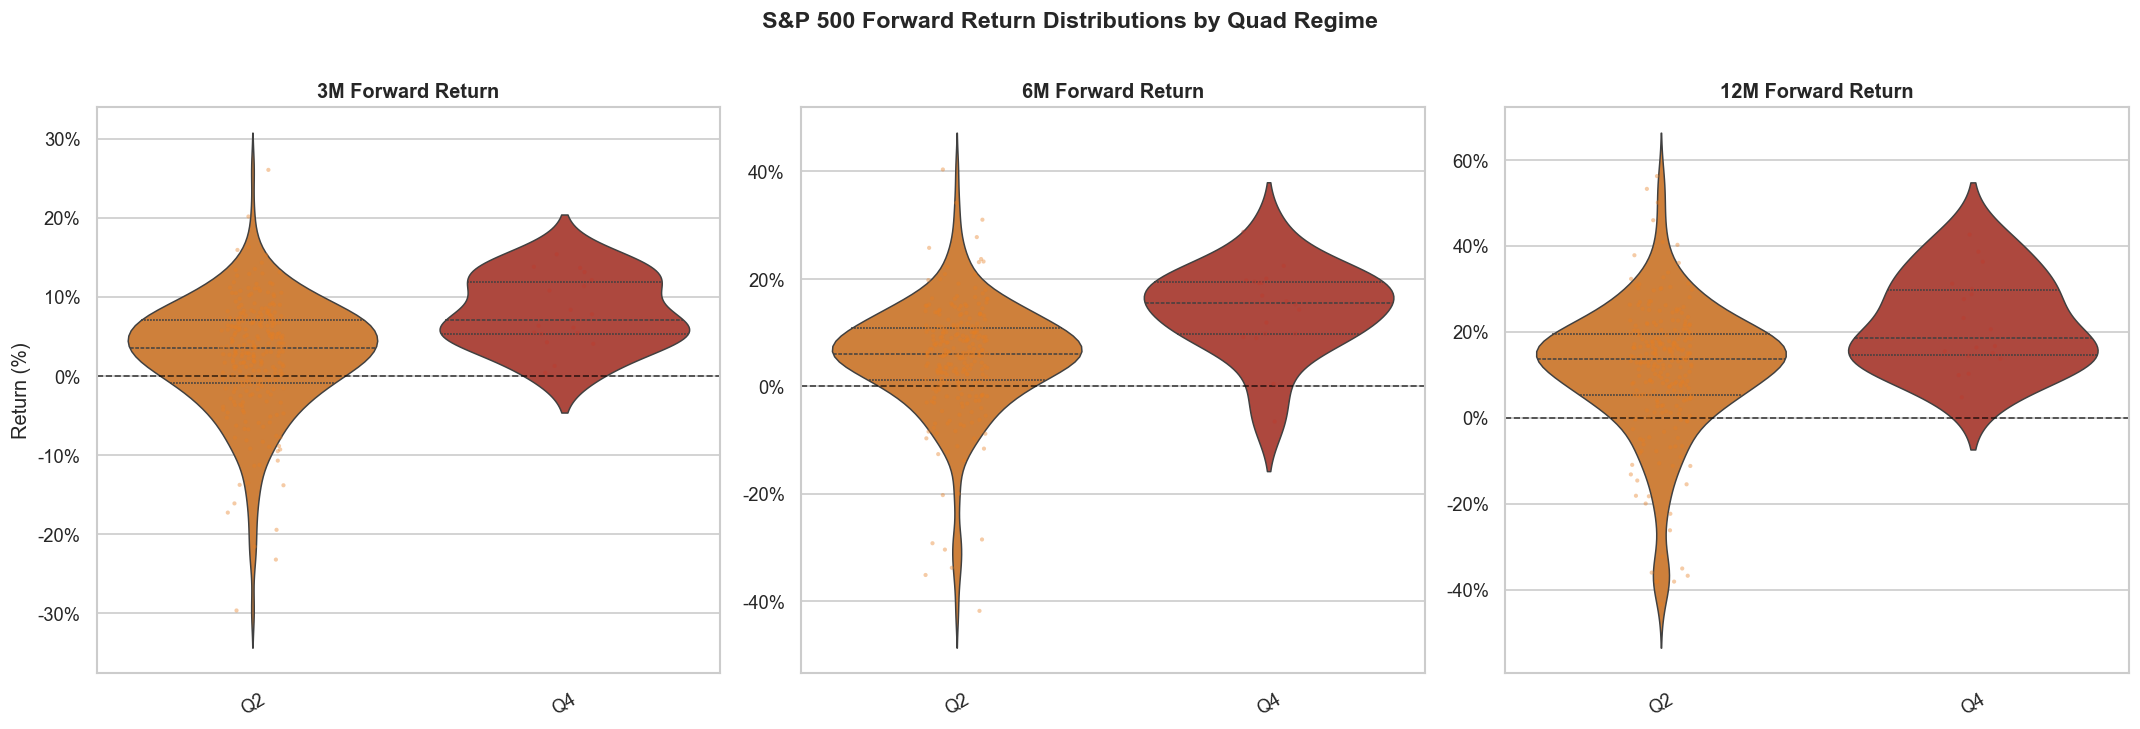

In [10]:
# ── Violin + strip plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

short_labels = {q: QUAD_LABELS[q].split('—')[0].strip() for q in range(1, 5)}
palette      = {short_labels[q]: QUAD_COLORS[q] for q in range(1, 5)}

for ax, label in zip(axes, HORIZONS):
    col = f'fwd_{label}'
    df_plot = analysis[['regime', col]].dropna().copy()
    df_plot['Regime'] = df_plot['regime'].map(short_labels)

    sns.violinplot(data=df_plot, x='Regime', y=col, palette=palette,
                   inner='quartile', density_norm='width', ax=ax, linewidth=0.9)
    sns.stripplot(data=df_plot, x='Regime', y=col, palette=palette,
                  size=2.5, alpha=0.4, jitter=True, ax=ax)

    ax.axhline(0, color='black', lw=1.0, linestyle='--', alpha=0.7)
    ax.set_title(f'{label} Forward Return', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Return (%)' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('S&P 500 Forward Return Distributions by Quad Regime',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

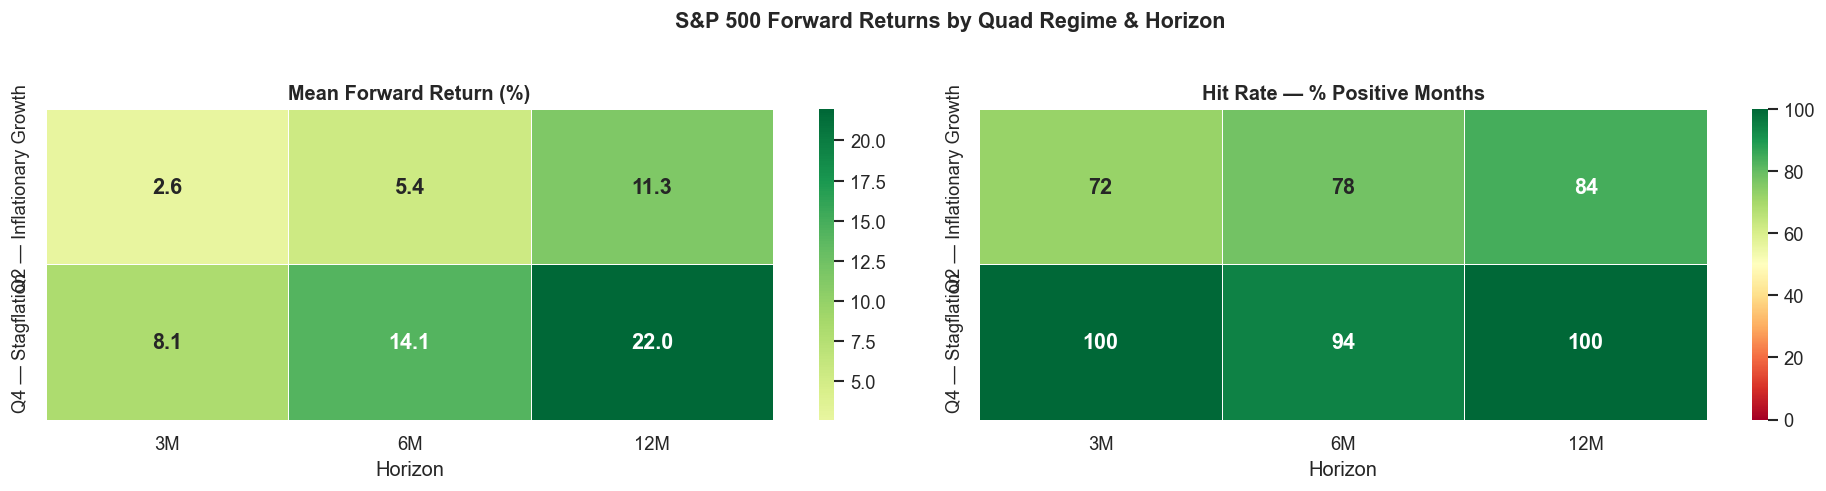

In [11]:
# ── Mean Return & Hit Rate heatmaps ───────────────────────────────────────────
def build_regime_table(df, func):
    return pd.DataFrame({
        h: df.groupby('regime')[f'fwd_{h}'].apply(func).rename(index=QUAD_LABELS)
        for h in HORIZONS
    })

mean_tbl = build_regime_table(analysis, lambda s: s.dropna().mean())
hit_tbl  = build_regime_table(analysis, lambda s: (s.dropna() > 0).mean() * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(mean_tbl, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'}, ax=ax1)
ax1.set_title('Mean Forward Return (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Horizon'); ax1.set_ylabel('')

sns.heatmap(hit_tbl, annot=True, fmt='.0f', cmap='RdYlGn', center=50,
            vmin=0, vmax=100, linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'}, ax=ax2)
ax2.set_title('Hit Rate — % Positive Months', fontsize=12, fontweight='bold')
ax2.set_xlabel('Horizon'); ax2.set_ylabel('')

plt.suptitle('S&P 500 Forward Returns by Quad Regime & Horizon',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

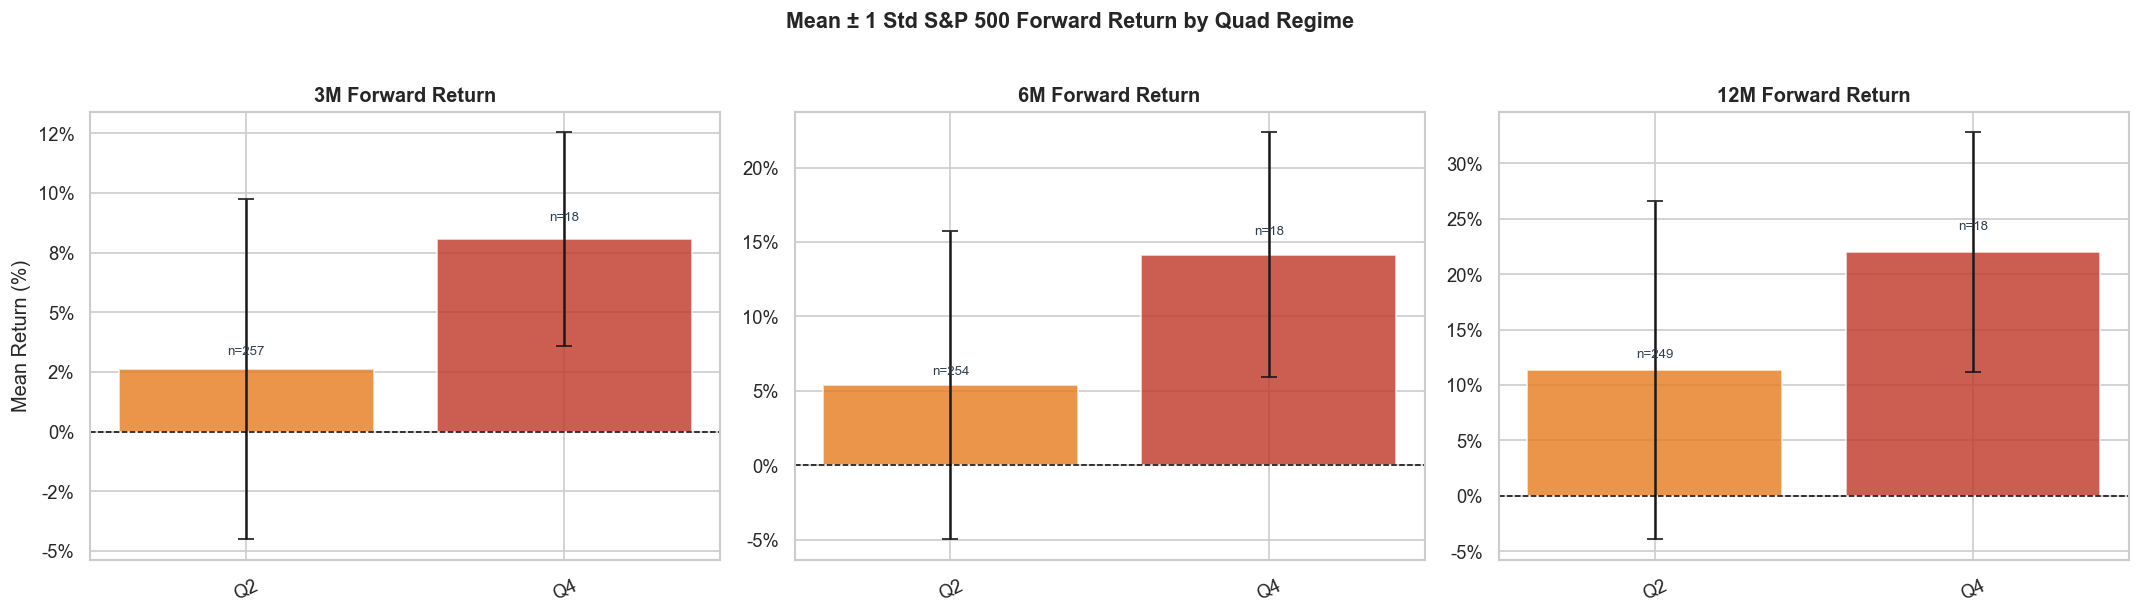

In [12]:
# ── Mean ± 1 Std bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, HORIZONS):
    col = f'fwd_{label}'
    grp = analysis.dropna(subset=[col]).groupby('regime')[col]
    quads  = sorted(grp.groups.keys())
    means  = [grp.get_group(q).mean() for q in quads]
    stds   = [grp.get_group(q).std()  for q in quads]
    ns     = [grp.get_group(q).dropna().shape[0] for q in quads]
    xlbls  = [short_labels[int(q)] for q in quads]
    colors = [QUAD_COLORS[int(q)] for q in quads]

    bars = ax.bar(xlbls, means, yerr=stds, color=colors, alpha=0.82,
                  capsize=5, edgecolor='white')
    for bar, mean_v, n in zip(bars, means, ns):
        offset = max(abs(mean_v) * 0.08, 0.5) * (1 if mean_v >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width() / 2,
                mean_v + offset, f'n={n}',
                ha='center', va='bottom', fontsize=8, color='#2c3e50')

    ax.axhline(0, color='black', lw=0.9, linestyle='--')
    ax.set_title(f'{label} Forward Return', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Return (%)' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Mean ± 1 Std S&P 500 Forward Return by Quad Regime',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Key Observations

| Regime | Economic Narrative | Typical Equity Outcome |
|---|---|---|
| **Q1 — Disinflationary Growth** | Goldilocks: growth expands while inflation falls. Fed can stay accommodative. | Historically strongest for equities |
| **Q2 — Inflationary Growth** | Boom: strong demand drives both activity and prices. Fed typically tightening. | Positive but increasingly volatile late-cycle |
| **Q3 — Deflationary Recession** | Credit bust / demand collapse (e.g., GFC). Deflation risk, aggressive easing follows. | Mixed; recovery moves can be sharp |
| **Q4 — Stagflation** | Weakening growth with rising inflation. Worst macro mix for risk assets. | Historically weakest for equities |

**Caveats**
- `CPILFENS` is **Core CPI** (all items ex-food & energy). Headline CPI may shift classification around commodity-driven deflation episodes (e.g., 2014–2016 oil collapse).
- GDP vintage data covers 2002 Q1–present; the analysis window is bounded by the overlapping period with both SPX data and GDP availability.
- Regime boundaries use a strict zero threshold; a **rate-of-change** (acceleration vs. deceleration) framework would produce materially different classifications.
- Forward returns use end-of-month prices only — intra-month entry timing is not captured.